In [14]:
local_config_path = "local_config_zam_mad.yaml"
fcst_yaml_path = "forecast_zam_mad_orig_lead30.yaml"

In [15]:
import xarray as xr
import yaml
import os
import sys

def read_config():
    config_path = local_config_path
    try:
        with open(config_path, 'r') as f:
            try:
                localconfig = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(e)
                sys.exit(1)
            return localconfig
    except FileNotFoundError as e:
        print(e)
        print("You must set local_config.yaml in the main folder. Copy local_config-example.yaml and adjust appropriately.")
        sys.exit(1)


def get_data_paths():
    data_config_paths = 'data_paths.yaml'

    try:
        with open(data_config_paths, 'r') as f:
            try:
                all_data_paths = yaml.safe_load(f)
            except yaml.YAMLError as e:
                print(e)
                sys.exit(1)
    except FileNotFoundError as e:
        print(e)
        print("data_paths.yaml not found. Should exist in main folder")
        sys.exit(1)

    lc = read_config()
    data_paths = all_data_paths[lc['data_paths']]
    return data_paths

In [16]:
with open(fcst_yaml_path, "r") as f:
    try:
        fcst_params = yaml.safe_load(f)
    except yaml.YAMLError as exc:
        print(exc)
        raise

output_folder = fcst_params["OUTPUT"]["folder"]
save_crps_only = fcst_params["OUTPUT"]["save_crps_only"]
truth_input_folder = fcst_params["INPUT"]["truth_folder"]

In [17]:
files = os.listdir(output_folder)
print(len(files), "files found")

125 files found


In [18]:
file_path = files[10] # Pick a random file

fcst = xr.load_dataset(f"{output_folder}/{file_path}")
fcst

<xarray.Dataset>
Dimensions:          (latitude: 384, longitude: 352, member: 10, time: 1,
                      valid_time: 1)
Coordinates:
  * latitude         (latitude) float32 -35.05 -34.95 -34.85 ... 3.05 3.15 3.25
  * longitude        (longitude) float32 15.95 16.05 16.15 ... 50.85 50.95 51.05
  * member           (member) int32 1 2 3 4 5 6 7 8 9 10
  * time             (time) datetime64[ns] 2021-02-17
Dimensions without coordinates: valid_time
Data variables:
    fcst_valid_time  (time, valid_time) datetime64[ns] 2021-02-18T06:00:00
    precipitation    (time, member, valid_time, latitude, longitude) float32 ...
    crps             (time, valid_time, latitude, longitude) float32 0.005454...
Attributes:
    description:  GAN 24-hour rainfall ensemble members in the ICPAC region.

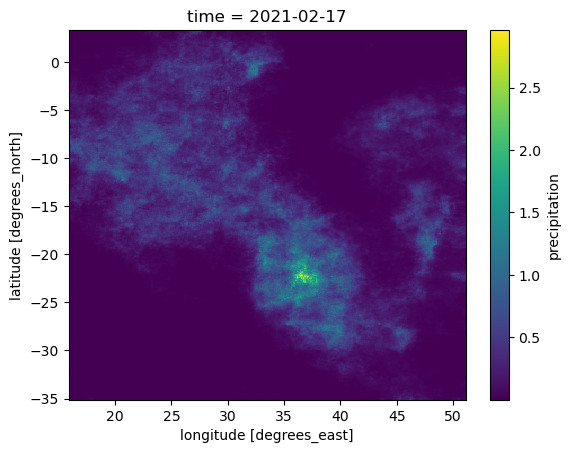

In [19]:
#plot precip if present
if not save_crps_only:
    fcst.precipitation.median('member').isel(valid_time=0, time=0).plot()

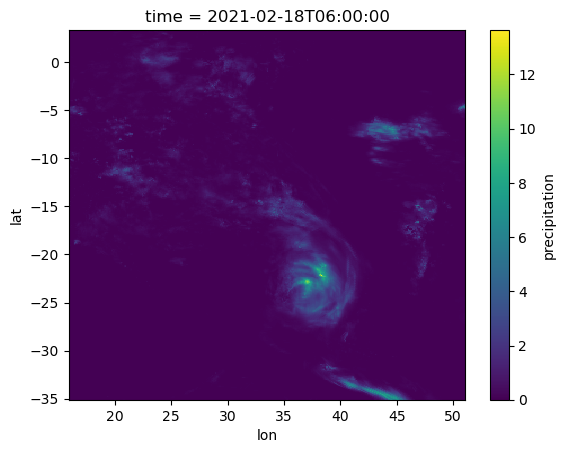

In [20]:
#plot truth
time = fcst.fcst_valid_time[0]
truth = xr.load_dataset(f"{truth_input_folder}/{str(time.dt.year.values[0])}/{time.dt.strftime('%Y%m%d').values[0]}_06.nc")
truth.precipitation.isel(time=0).plot()


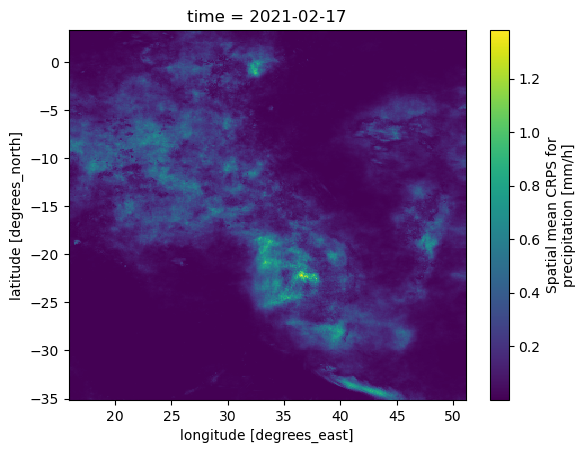

In [21]:
#plot crps
fcst.crps.isel(valid_time=0, time=0).plot()

In [23]:
#Plot CRPS
fcsts = xr.open_mfdataset((f"{output_folder}/{f}" for f in files), combine="by_coords")
fcsts = fcsts.where(fcsts.crps < 1e36) #remove missing values

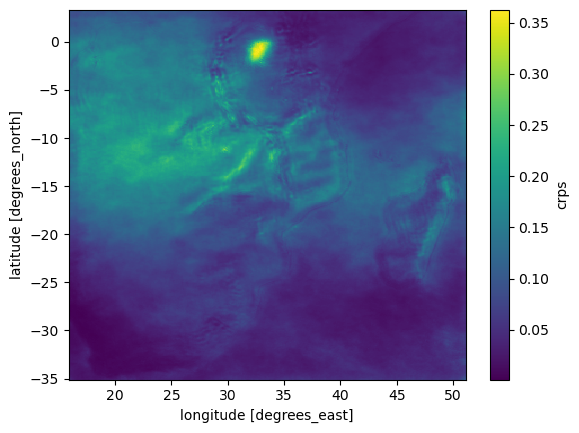

In [24]:
fcsts.crps.mean('time').plot()